## Pipeline for all complex tissue datasets

In [ ]:
# please specify which dataset you want to process:
# available options: PBMC, PFC
# WBC is not available for CellClear due to incompatibility with well-plate-based platform data
dataset = "PBMC"

# please specifiy path for reading input files
PATH = dataset.lower()

# CellClear requires raw and filtered 10x mtx directories, those file_dir will be created
# upon reading input files!
RAW_FILE_DIR = "10x_mtx_raw"
FILTERED_FILE_DIR = "10x_mtx_filtered"

In [ ]:
import subprocess
import os
import zipfile

dataset_dir = os.path.join(dataset.lower())
os.makedirs(dataset_dir, exist_ok=True)

def download_if_needed(url, target_dir):
    filename = url.split("/")[-1]

    if "figshare.com" in url:
        filename = "raw.zip"

    output_path = os.path.join(target_dir, filename)

    if os.path.exists(output_path):
        print(f"File exists – resume if needed: {filename}")
        subprocess.run([
            "curl", "-L", "-C", "-", "-o", output_path, url
        ], check=True)
    else:
        print(f"Download: {filename}")
        subprocess.run([
            "curl", "-L", "-o", output_path, url
        ], check=True)

def download_pfc_if_needed(url, base_dir, filename):
    if "filtered" in filename:
        target_dir = os.path.join(base_dir, "filtered")
    elif "raw" in filename:
        target_dir = os.path.join(base_dir, "raw")
    else:
        target_dir = base_dir
    os.makedirs(target_dir, exist_ok=True)
    output_path = os.path.join(target_dir, filename)

    if os.path.exists(output_path):
        print(f"Resume: {filename}")
        subprocess.run([
            "curl", "-L", "-C", "-", "--fail",
            "-o", output_path, url
        ], check=True)
    else:
        print(f"Download: {filename}")
        subprocess.run([
            "curl", "-L", "--fail",
            "-o", output_path, url
        ], check=True)

def extract_gz_files(directory):
    for filename in os.listdir(directory):
        if filename.endswith(".gz"):
            filepath = os.path.join(directory, filename)

            print(f"Extracting (gunzip): {filename}")

            subprocess.run([
                "gunzip", "-f", filepath  
            ], check=True)

def extract_flat(zip_path, target_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        for member in zip_ref.namelist():
            # nur Dateien (keine Ordner)
            if not member.endswith("/"):
                filename = os.path.basename(member)  # entfernt "raw/"
                target_path = os.path.join(target_dir, filename)

                with open(target_path, "wb") as f:
                    f.write(zip_ref.read(member))

if dataset == "PBMC":
    urls = [
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
        "https://cf.10xgenomics.com/samples/cell-exp/9.0.0/60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex/60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex_count_raw_feature_bc_matrix.h5"
    ]

elif dataset == "WBC":
    urls = [
        "https://ndownloader.figshare.com/files/41209533",
    ]

elif dataset == "PFC":
    urls = [
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138509&format=file&file=GSM5138509_RL2103_ga22_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138509_ga22_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138509&format=file&file=GSM5138509_RL2103_ga22_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138509_ga22_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138511&format=file&file=GSM5138511_RL2107_ga24_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138511_ga24_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138511&format=file&file=GSM5138511_RL2107_ga24_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138511_ga24_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138513&format=file&file=GSM5138513_RL2121_ga34_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138513_ga34_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138513&format=file&file=GSM5138513_RL2121_ga34_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138513_ga34_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138514&format=file&file=GSM5138514_RL1777_1m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138514_1m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138514&format=file&file=GSM5138514_RL1777_1m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138514_1m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138516&format=file&file=GSM5138516_RL1612_2m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138516_2m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138516&format=file&file=GSM5138516_RL1612_2m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138516_2m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138517&format=file&file=GSM5138517_RL2100_3m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138517_3m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138517&format=file&file=GSM5138517_RL2100_3m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138517_3m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138519&format=file&file=GSM5138519_RL2104_4m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138519_4m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138519&format=file&file=GSM5138519_RL2104_4m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138519_4m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138520&format=file&file=GSM5138520_RL2108_6m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138520_6m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138520&format=file&file=GSM5138520_RL2108_6m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138520_6m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138522&format=file&file=GSM5138522_RL2122_10m_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138522_10m_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138522&format=file&file=GSM5138522_RL2122_10m_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138522_10m_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138524&format=file&file=GSM5138524_RL2125_1y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138524_1y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138524&format=file&file=GSM5138524_RL2125_1y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138524_1y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138528&format=file&file=GSM5138528_RL1613_2y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138528_2y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138528&format=file&file=GSM5138528_RL1613_2y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138528_2y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138530&format=file&file=GSM5138530_RL2129_3y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138530_3y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138530&format=file&file=GSM5138530_RL2129_3y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138530_3y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138531&format=file&file=GSM5138531_RL2109_4y_snRNAseq_filtered_bc_matrix.h5.gz", "GSM5138531_4y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138531&format=file&file=GSM5138531_RL2109_4y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138531_4y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138533&format=file&file=GSM5138533_RL2106_6y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138533_6y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138533&format=file&file=GSM5138533_RL2106_6y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138533_6y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138535&format=file&file=GSM5138535_RL1614_8y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138535_8y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138535&format=file&file=GSM5138535_RL1614_8y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138535_8y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138537&format=file&file=GSM5138537_RL2110_10y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138537_10y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138537&format=file&file=GSM5138537_RL2110_10y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138537_10y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138540&format=file&file=GSM5138540_RL2127_12y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138540_12y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138540&format=file&file=GSM5138540_RL2127_12y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138540_12y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138541&format=file&file=GSM5138541_RL2130_14y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138541_14y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138541&format=file&file=GSM5138541_RL2130_14y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138541_14y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138543&format=file&file=GSM5138543_RL2102_16y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138543_16y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138543&format=file&file=GSM5138543_RL2102_16y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138543_16y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138545&format=file&file=GSM5138545_RL2131_17y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138545_17y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138545&format=file&file=GSM5138545_RL2131_17y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138545_17y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138546&format=file&file=GSM5138546_RL2123_20y_a_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138546_20y_a_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138546&format=file&file=GSM5138546_RL2123_20y_a_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138546_20y_a_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138549&format=file&file=GSM5138549_RL2132_25y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138549_25y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138549&format=file&file=GSM5138549_RL2132_25y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138549_25y_raw.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138551&format=file&file=GSM5138551_RL2124_40y_snRNAseq_filtered_feature_bc_matrix.h5.gz", "GSM5138551_40y_filtered.h5.gz"),
        ("https://www.ncbi.nlm.nih.gov/geo/download/?acc=GSM5138551&format=file&file=GSM5138551_RL2124_40y_snRNAseq_raw_feature_bc_matrix.h5.gz", "GSM5138551_40y_raw.h5.gz"),
    ]


else:
    raise ValueError("Unknown dataset")

if dataset == "PBMC":
    for url in urls:
        download_if_needed(url, dataset_dir)
elif dataset == "WBC":
    for url in urls:
        download_if_needed(url, dataset_dir)    
    zip_path = os.path.join(dataset_dir, "raw.zip")
    extract_flat(zip_path, dataset_dir)
elif dataset == "PFC":
    for url, filename in urls:
        download_pfc_if_needed(url, dataset_dir, filename)
    extract_gz_files(os.path.join(dataset_dir, "filtered"))
    extract_gz_files(os.path.join(dataset_dir, "raw"))
else:
    raise ValueError("Dataset needs to beither PBMC, WBC or PFC!")

In [2]:
import os
import pandas as pd
import scipy.io
import scipy.sparse as sp
import gzip

def write_10x_mtx(adata, out_base_dir, dataset_type="raw", compress=False):
    """
    Write an AnnData object to 10x Genomics MTX format.

    Parameters
    ----------
    adata : anndata.AnnData
        AnnData object to export.
    out_base_dir : str
        Base output directory.
    dataset_type : str, optional (default="raw")
        Either "raw" or "filtered". This will be appended to the output folder name.
    compress : bool, optional (default=False)
        If True, output files will be gzipped (.gz).

    Output
    ------
    Creates a directory:
        <out_base_dir>/10x_mtx_<dataset_type>/

    With files:
        - matrix.mtx (or .mtx.gz)
        - barcodes.tsv (or .tsv.gz)
        - features.tsv (or .tsv.gz)
    """

    # Validate dataset type
    if dataset_type not in ["raw", "filtered"]:
        raise ValueError("dataset_type must be 'raw' or 'filtered'")

    # Create output directory
    out_dir = os.path.join(out_base_dir, f"10x_mtx_{dataset_type}")
    os.makedirs(out_dir, exist_ok=True)

    # Ensure matrix is sparse (10x format expects sparse matrix)
    X = adata.X
    if not sp.issparse(X):
        X = sp.csr_matrix(X)

    # Transpose matrix (genes x cells format required by 10x)
    matrix = X.T

    # 1. Write matrix
    matrix_path = os.path.join(out_dir, "matrix.mtx")

    if compress:
        with gzip.open(matrix_path + ".gz", "wb") as f:
            scipy.io.mmwrite(f, matrix)
    else:
        scipy.io.mmwrite(matrix_path, matrix)

    # 2. Write barcodes (cell names)
    barcodes_path = os.path.join(out_dir, "barcodes.tsv")

    if compress:
        with gzip.open(barcodes_path + ".gz", "wt") as f:
            adata.obs_names.to_series().to_csv(
                f, sep="\t", index=False, header=False
            )
    else:
        adata.obs_names.to_series().to_csv(
            barcodes_path, sep="\t", index=False, header=False
        )

    # 3. Write features (gene annotations)
    # Use gene_ids if available, otherwise fallback to var_names
    if "gene_ids" in adata.var.columns:
        gene_ids = adata.var["gene_ids"]
    else:
        gene_ids = adata.var_names

    features = pd.DataFrame({
        "gene_ids": gene_ids,
        "gene_name": adata.var_names,
        "feature_types": ["Gene Expression"] * adata.n_vars,
    })

    features_path = os.path.join(out_dir, "features.tsv")

    if compress:
        with gzip.open(features_path + ".gz", "wt") as f:
            features.to_csv(f, sep="\t", index=False, header=False)
    else:
        features.to_csv(features_path, sep="\t", index=False, header=False)

    print(f"10x MTX ({dataset_type}) written to: {out_dir}")

In [2]:
import scanpy as sc
import seaborn as sns
import numpy as np
import anndata as ad
from scipy.stats import median_abs_deviation
from matplotlib import pyplot as plt
import celltypist
from celltypist import models
import pandas as pd
from os import listdir
from scipy import io

/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/celltypist/classifier.py:11: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  from scanpy import __version__ as scv


In [4]:
file_paths = [
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor1_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor2_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor3_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5",
    f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Human_Donor4_PBMC_TotalSeqB_hashing_3p_gem-x_count_sample_filtered_feature_bc_matrix.h5"
]

def load_and_concat_10x_pbmc(file_paths):
    """
    Loads all 10x h5 files from a directory and combines them into one AnnData object
    
    parameters
    ----------
    file_paths : list of str
        list with paths to AnnData objects
        
    returns
    -------
    adata : AnnData
        concatenated AnnData object with sample information
    """

    adatas = []

    for i, path in enumerate(file_paths):
        ada = sc.read_10x_h5(path)
        ada.var_names_make_unique()
        ada.obs['sample'] = f'sample_{i+1}'
        adatas.append(ada)

    adata = ad.concat(adatas, join="outer", label="sample", merge="first")

    return adata

In [5]:
def load_bd_data(matrix_path, barcodes_path, features_path, metadata_path):
    """
    Load BD Rhapsody single-cell data (MTX format) along with metadata into an AnnData object.

    Parameters
    ----------
    matrix_path : str
        Path to the matrix.mtx (can be gzipped).
    barcodes_path : str
        Path to the barcodes.tsv file.
    features_path : str
        Path to the genes/features.tsv file.
    metadata_path : str
        Path to the metadata.tsv file.

    Returns
    -------
    adata : anndata.AnnData
        AnnData object containing expression matrix, metadata, and gene annotations.
    """

    # Load sparse matrix and transpose (cells should be rows)
    X = io.mmread(matrix_path).tocsc().T

    # Load barcodes and convert to strings
    barcodes = pd.read_csv(barcodes_path, header=None, sep='\t')[0].astype(str)

    # Optionally create standardized cell names
    barcodes.index = [f"cell_{bc}" for bc in barcodes]

    # Load feature (gene) information
    features = pd.read_csv(features_path, header=None, sep='\t')
    gene_ids = features[0].values
    gene_names = features[1].values
    feature_types = features[2].values

    # Load metadata and align with barcodes
    metadata = pd.read_csv(metadata_path, sep='\t')
    metadata.index = metadata["CELL"]
    metadata = metadata.drop(columns=["CELL"])

    # Reorder metadata to match barcode order
    metadata = metadata.loc[barcodes]

    # Create AnnData object
    adata = ad.AnnData(X=X, obs=metadata)

    # Add gene annotations
    adata.var["gene_ids"] = gene_ids
    adata.var["gene_symbols"] = gene_names
    adata.var["feature_types"] = feature_types

    # Set gene names as variable names
    adata.var_names = gene_names  # alternatively: gene_ids

    # Set cell names
    adata.obs_names = barcodes.values  # should match metadata.index

    return adata

In [6]:
def load_and_concatenate_10x_pfc(data_in_path):
    """
    Loads all 10x h5 files from a directory and combines them into one AnnData object
    
    expected file format:
    RUNID_AGE_Chemistry_filetypename.h5
    
    parameters
    ----------
    data_in_path : str
        path to folder with .h5 files
        
    returns
    -------
    adata : AnnData
        concatenated AnnData object with batch information
    """

    file_list = np.sort(listdir(data_in_path))
    adata_list = []

    for fl_itr in file_list:
        fl_ids = fl_itr.split('_')

        adata_itr = sc.read_10x_h5(os.path.join(data_in_path, fl_itr), genome=None)

        # genome-Spalte entfernen (Problem bei concatenate)
        if 'genome' in adata_itr.var.columns:
            adata_itr.var.drop(labels='genome', axis=1, inplace=True)

        adata_itr.var['non-unique_names'] = adata_itr.var_names
        adata_itr.var_names_make_unique()

        adata_itr.obs['batch'] = "_".join(fl_ids[:2])
        adata_itr.obs['RL#'] = fl_ids[0]
        adata_itr.obs['age'] = fl_ids[1]

        adata_list.append(adata_itr)

    adata = sc.AnnData.concatenate(*adata_list, join='inner', batch_key="concat_id")

    # Barcodes neu formatieren
    barcodes = np.array([
        ii.split('-')[0] + '-' + jj
        for ii, jj in zip(adata.obs_names, adata.obs['batch'])
    ])
    adata.obs_names = barcodes

    return adata

In [ ]:
# Load anndata object, 
if dataset == "WBC":
    raise ValueError("CellClear does not work with data from well-plate-based platforms like the WBC dataset!")
elif dataset == "PFC":
    adata_raw = load_and_concatenate_10x_pfc(f"{PATH}/raw")
    write_10x_mtx(adata_raw, out_base_dir=PATH, dataset_type="raw", compress=True)
    adata = load_and_concatenate_10x_pfc(f"{PATH}/filtered")
    write_10x_mtx(adata, out_base_dir=PATH, dataset_type="filtered", compress=True)
else:
    adata_raw = sc.read_10x_h5(f"{PATH}/60k_Human_TotalSeqB_hashing_3p_gem-x_Multiplex_count_raw_feature_bc_matrix.h5")
    adata_raw.var_names_make_unique()
    write_10x_mtx(adata_raw, out_base_dir=PATH, dataset_type="raw", compress=True)
    adata = load_and_concat_10x_pbmc(file_paths)
    write_10x_mtx(adata, out_base_dir=PATH, dataset_type="filtered", compress=True)

### Ambient RNA correction with CellClear

In [ ]:
import subprocess
if dataset != "WBC":
    # please specify raw file name or 10x dir
    filtered_file = f"{PATH}/{FILTERED_FILE_DIR}"
    raw_file = f"{PATH}/{RAW_FILE_DIR}"
    output_file = f"{dataset}_cellclear"

    cmd = [
        "CellClear", "correct_expression",
        "--filtered_mtx_path", filtered_file,
        "--raw_mtx_path", raw_file,
        "--prefix", output_file,
        "--output", ".",
    ]

    print("Running:", " ".join(cmd))

    subprocess.run(cmd)

Running: CellClear correct_expression --filtered_mtx_path ../chromium/10x_mtx_filtered --raw_mtx_path ../chromium/10x_mtx_raw --prefix PBMC_cellclear --output .


/home/luschroe/miniconda3/envs/benchmarking/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


Loading data from directory ../chromium/10x_mtx_filtered
Loading data from directory ../chromium/10x_mtx_raw
Final umis range used: [60, 170]
Fetch clustering info from data...
Find background barcodes that exhibit similar expression patterns to the foreground cluster...
0 out of 8823 cell barcodes failed for deconvolution...
30 background cells will be used to perform smooth spline...
Perform smooth spline...
Contamination Genes: MALAT1,TALAM1,TXNIP,SKAP1,SMCHD1,PTMA,TPT1,BTG1,TMSB10,EEF1A1,HLA-C,FOXP1,TRBC2,HLA-E,RACK1,SYNE2,HLA-A,USP15,ETS1,IL32
Contamination Level: 0.107
Potential ambient topic include Topic_19,Topic_2,Topic_25,Topic_16,Topic_28,Topic_13,Topic_6,Topic_27,Topic_7,Topic_11,Topic_21,Topic_14,Topic_20,Topic_3,Topic_8,Topic_10,Topic_12,Topic_23,Topic_26,Topic_1...
Totally find 1632 ambient genes...
Start removing ambient expression...


Processing Topic_13:   1%|          | 8/720 [01:08<47:41,  4.02s/it]  

Processing Topic_25:   0%|          | 0/422 [00:00<?, ?it/s]

Processing Topic_25:   0%|          | 1/422 [00:25<2:56:29, 25.15s/it]

Processing Topic_25:   0%|          | 2/422 [00:35<1:53:25, 16.20s/it]

Processing Topic_25:   1%|          | 3/422 [00:42<1:24:22, 12.08s/it]

Processing Topic_25:   1%|          | 4/422 [00:48<1:08:04,  9.77s/it]

Processing Topic_25:   1%|          | 5/422 [00:54<58:51,  8.47s/it]  

Processing Topic_25:   1%|▏         | 6/422 [00:55<40:29,  5.84s/it]

Processing Topic_25:   2%|▏         | 7/422 [00:55<28:31,  4.12s/it]

Processing Topic_25:   2%|▏         | 8/422 [00:56<19:55,  2.89s/it]

Processing Topic_25:   2%|▏         | 9/422 [00:56<14:05,  2.05s/it]

Processing Topic_25:   2%|▏         | 10/422 [00:57<12:39,  1.84s/it]

Processing Topic_25:   3%|▎         | 11/422 [00:59<11:16,  1.65s/it]

Processing Topic_25:   3%|▎         | 12/422 [00:59<08:59,  1.32s/it]

Processing To

In [ ]:
adata = sc.read_10x_mtx(f"./matrix")
adata.var_names_make_unique()

In [ ]:
# save raw counts for compatibility with celltypist later
common = adata.obs_names.intersection(adata_raw.obs_names)
subset = adata_raw[common]
adata.layers["raw"] = subset.X.copy()
# fetch batch information from original file
if dataset == "PFC":
    adata.obs["batch"] = subset.obs["batch"].copy()

In [ ]:
del subset

In [12]:
del adata_raw

In [13]:
adata.layers["corr"] = adata.X.copy()

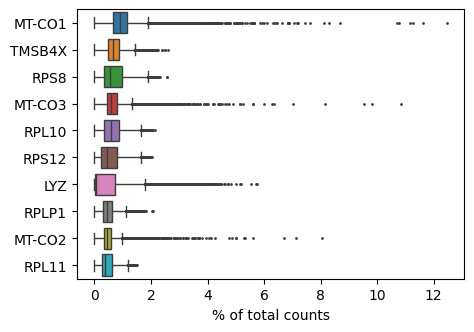

In [14]:
# inspect highest expressed genes
sc.pl.highest_expr_genes(adata, n_top=10)

### Quality Control

In [15]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [16]:
sc.pp.calculate_qc_metrics(
    adata, qc_vars=["mt", "ribo", "hb"], inplace=True, percent_top=[20], log1p=True
)
adata

AnnData object with n_obs × n_vars = 39658 × 38606
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_20_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    layers: 'raw', 'corr'

... storing 'feature_types' as categorical


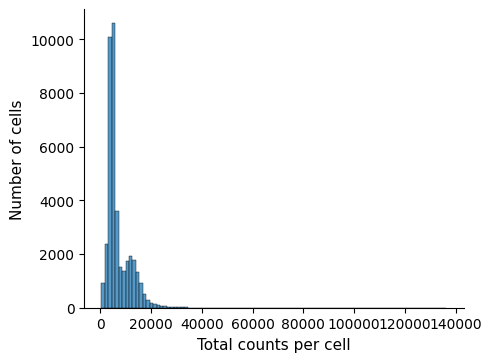

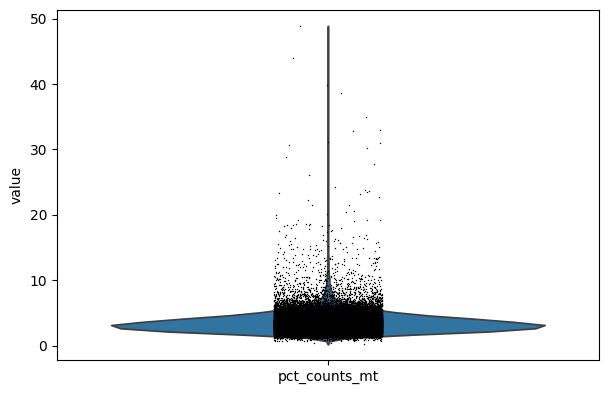

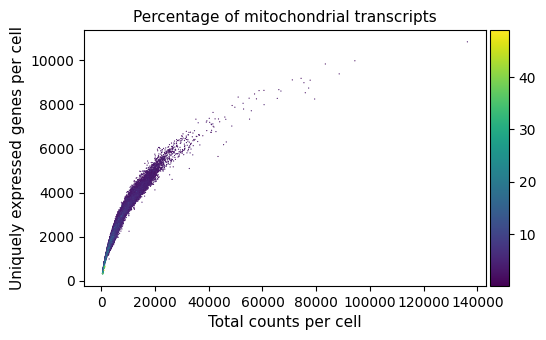

In [17]:
# plot quality metrics
p1 = sns.displot(adata.obs["total_counts"], bins=100, kde=False)
p1.set_axis_labels("Total counts per cell", "Number of cells", fontsize=11)
p1.figure.set_size_inches(5, 3.5)
p2 = sc.pl.violin(adata, "pct_counts_mt")
p3 = sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt", show=False)
p3.set_xlabel("Total counts per cell", fontsize=11)
p3.set_ylabel("Uniquely expressed genes per cell", fontsize=11)
p3.set_title("Percentage of mitochondrial transcripts", fontsize=11)
p3.figure.set_size_inches(6, 3.5)

In [18]:
# MAD tresholding
def is_outlier(adata, metric: str, nmads: int, batch_key: str = None):
    """
    Outlier detection based on MAD (global oder batch-aware).
    """
    values = adata.obs[metric]
    outlier_flags = pd.Series(False, index=adata.obs.index, dtype=bool)

    if batch_key is None:
        # global
        M = values
        med = np.median(M)
        mad = median_abs_deviation(M, scale=1)
        if mad > 0:
            outlier_flags[:] = (M < med - nmads * mad) | (M > med + nmads * mad)
    else:
        # batch-aware
        for batch, idx in adata.obs.groupby(batch_key).groups.items():
            M = values.loc[idx]   
            med = np.median(M)
            mad = median_abs_deviation(M, scale=1)
            if mad == 0:
                continue
            outliers = (M < med - nmads * mad) | (M > med + nmads * mad)
            outlier_flags.loc[idx] = outliers

    return outlier_flags

In [19]:
if dataset == "PBMC":
    key = None
elif dataset == "WBC":
    key = "Cartridge"
else:
    key = "batch"

adata.obs["outlier"] = (
    is_outlier(adata, "log1p_total_counts", 5, batch_key=key)
    | is_outlier(adata, "log1p_n_genes_by_counts", 5, batch_key=key)
    | is_outlier(adata, "pct_counts_in_top_20_genes", 5, batch_key=key)
)
adata.obs.outlier.value_counts()

outlier
False    38914
True       744
Name: count, dtype: int64

In [20]:
# threshold differs between datasets
high_quality = ["PBMC", "PFC"]
if dataset in high_quality:
    threshold = 8
else:
    threshold = 20

adata.obs["mt_outlier"] = adata.obs["pct_counts_mt"] > threshold
adata.obs.mt_outlier.value_counts()

mt_outlier
False    39095
True       563
Name: count, dtype: int64

In [21]:
# remove outliers
print(f"Total number of cells: {adata.n_obs}")
adata = adata[(~adata.obs.outlier) & (~adata.obs.mt_outlier)].copy()
print(f"Number of cells after filtering of low quality cells: {adata.n_obs}")

Total number of cells: 39658
Number of cells after filtering of low quality cells: 38507


### Ambient RNA correction

In [ ]:
# ambient RNA was already corrected

In [22]:
# use float32 for compatibility with scrublet
adata.X = adata.X.astype(np.float32)
for layer in adata.layers:
    adata.layers[layer] = adata.layers[layer].astype(np.float32)

### Doublet Detection

In [23]:
# doublet detection using Scrublet
sc.pp.scrublet(adata, batch_key=key)

### Normalization

In [24]:
scales_counts = sc.pp.normalize_total(adata, target_sum=None, inplace=False)
# log1p transform
adata.layers["log1p_norm"] = sc.pp.log1p(scales_counts["X"], copy=True)

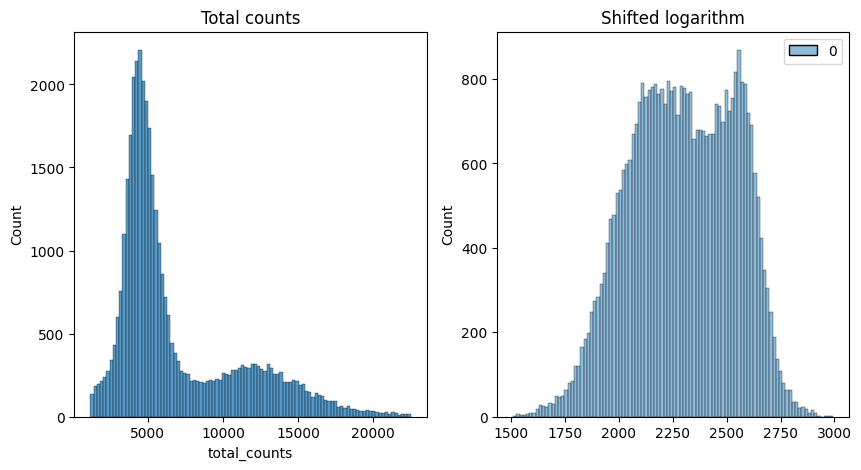

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
p1 = sns.histplot(adata.obs["total_counts"], bins=100, kde=False, ax=axes[0])
axes[0].set_title("Total counts")
p2 = sns.histplot(adata.layers["log1p_norm"].sum(1), bins=100, kde=False, ax=axes[1])
axes[1].set_title("Shifted logarithm")
plt.show()

### Feature selection

In [26]:
# pca was calculated without hvgs!
sc.pp.highly_variable_genes(adata, flavor='seurat_v3', n_top_genes=2000)

### Dimensionality Reduction

In [27]:
adata.X = adata.layers["log1p_norm"]

In [28]:
# scaling can improve PCA
sc.pp.scale(adata, max_value=10)

In [29]:
# use all genes not only hvgs
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=False)

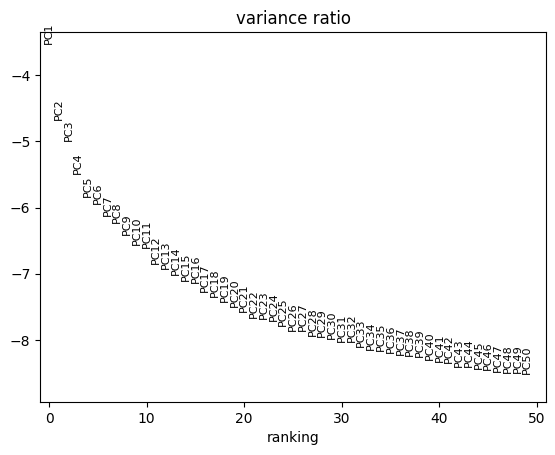

In [30]:
# compute variance ratio across Principal Component
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)

In [31]:
# compute tsne
sc.tl.tsne(adata, use_rep="X_pca")

In [32]:
# compute neighbors and umap
sc.pp.neighbors(adata, random_state=42)
sc.tl.umap(adata)

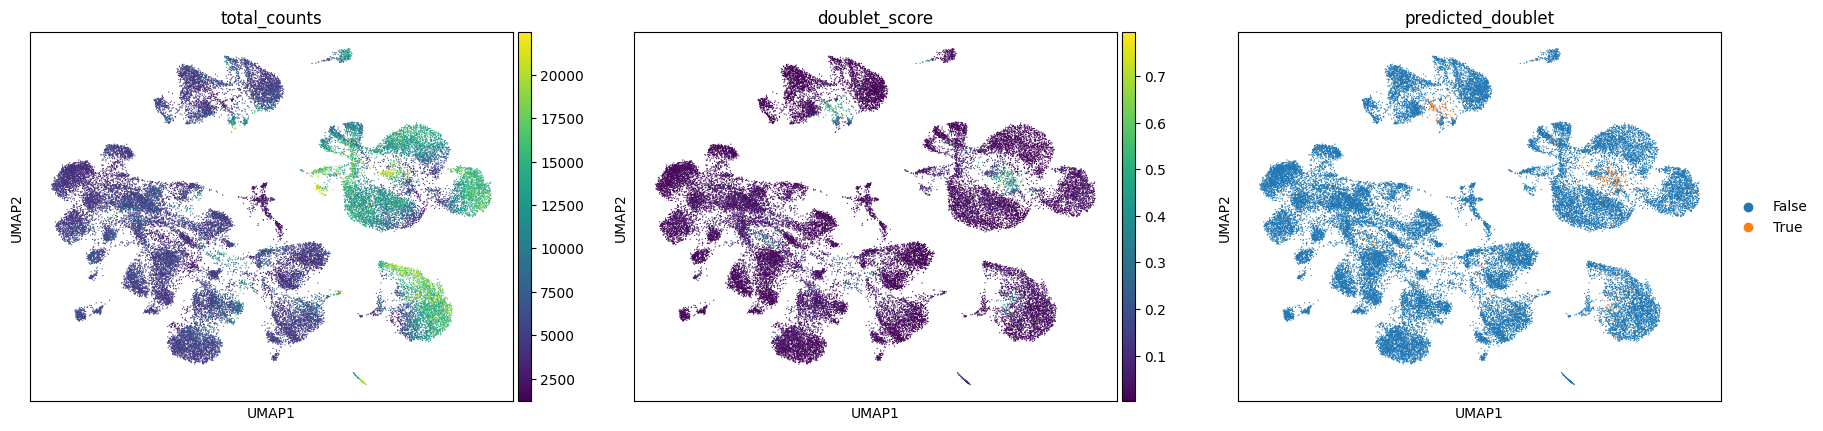

In [7]:
# inspecting quality control metrics
sc.pl.umap(
    adata,
    color=["total_counts", "doublet_score", "predicted_doublet"],
)

### Clustering

In [34]:
sc.tl.leiden(adata, key_added="leiden_res0_25", resolution=0.25)
sc.tl.leiden(adata, key_added="leiden_res0_5", resolution=0.5)
sc.tl.leiden(adata, key_added="leiden_res1", resolution=1.0)

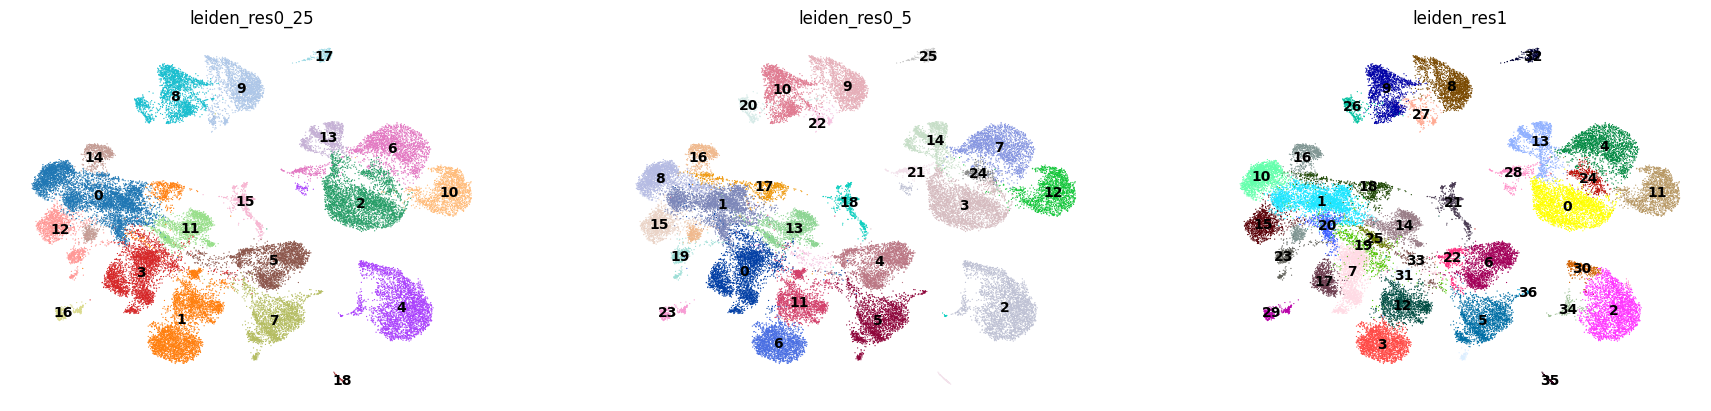

In [6]:
# inspect clustering
sc.pl.umap(
    adata,
    color=["leiden_res0_25", "leiden_res0_5", "leiden_res1"],
    legend_loc="on data",
    frameon=False
)

### Cell type annotation

In [ ]:
adata_celltypist = adata.copy()  # make a copy of our adata
adata_celltypist.X = adata.layers["corr"].copy()  # set adata.X to raw counts
sc.pp.normalize_total(
    adata_celltypist, target_sum=10**4
)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata_celltypist)  # log-transform
# make .X dense instead of sparse, for compatibility with celltypist:
adata_celltypist.X = adata_celltypist.X.toarray()

In [37]:
# chose the right model based on the used dataset, defaults to PBCMs
models.download_models(
    force_update=True, model=["Adult_Human_PrefrontalCortex.pkl", "Immune_All_High.pkl", "Immune_All_Low.pkl"]
)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 61
📂 Storing models in /home/luschroe/.celltypist/data/models
💾 Total models to download: 3
💾 Downloading model [1/3]: Immune_All_Low.pkl
💾 Downloading model [2/3]: Immune_All_High.pkl
💾 Downloading model [3/3]: Adult_Human_PrefrontalCortex.pkl


In [38]:
if dataset == "PFC":
    model = models.Model.load(model="Adult_Human_PrefrontalCortex.pkl")
else:
    model_high = models.Model.load(model="Immune_All_High.pkl")
    model_low = models.Model.load(model="Immune_All_Low.pkl")  

In [39]:
if dataset == "PFC":
    predictions = celltypist.annotate(
        adata_celltypist, model=model, majority_voting=True
    )
else:
    predictions_high = celltypist.annotate(
        adata_celltypist, model=model_high, majority_voting=True
    )
    predictions_low = celltypist.annotate(
        adata_celltypist, model=model_low, majority_voting=True
    )

🔬 Input data has 38507 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 38507 cells and 38606 genes
🔗 Matching reference genes in the model
🧬 5824 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 15
🗳️ Majority voting the predictions
✅ Majority voting done!


In [40]:
if dataset == "PFC":
    predictions_adata = predictions.to_adata()
    adata.obs["celltypist_cell_label"] = predictions_adata.obs.loc[
        adata.obs.index, "majority_voting"
    ]
    adata.obs["celltypist_conf_score"] = predictions_adata.obs.loc[
        adata.obs.index, "conf_score"
    ]
else:
    predictions_high_adata = predictions_high.to_adata()
    adata.obs["celltypist_cell_label_coarse"] = predictions_high_adata.obs.loc[
        adata.obs.index, "majority_voting"
    ]
    adata.obs["celltypist_conf_score_coarse"] = predictions_high_adata.obs.loc[
        adata.obs.index, "conf_score"
    ]
    predictions_low_adata = predictions_low.to_adata()
    adata.obs["celltypist_cell_label_fine"] = predictions_low_adata.obs.loc[
        adata.obs.index, "majority_voting"
    ]
    adata.obs["celltypist_conf_score_fine"] = predictions_low_adata.obs.loc[
        adata.obs.index, "conf_score"
    ]

In [4]:
adata = sc.read_h5ad("../chromium/chromium_cellclear_processed.h5ad")

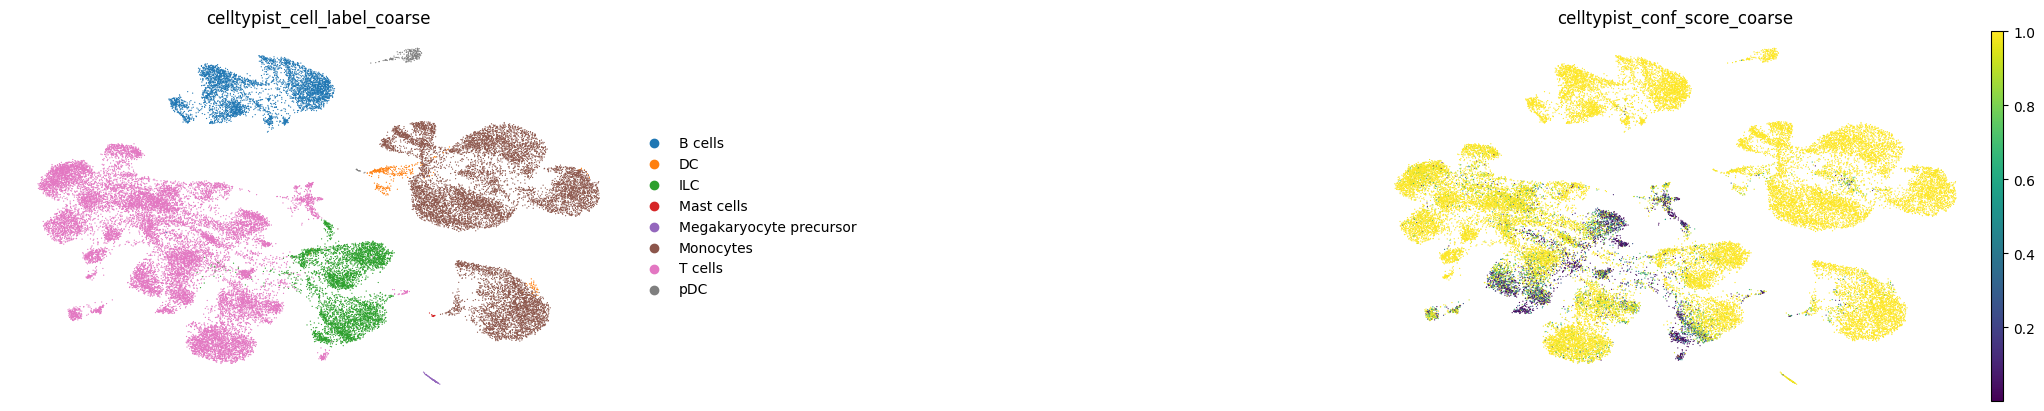

In [5]:
if dataset == "PFC":
    sc.pl.umap(
        adata,
        color=["celltypist_cell_label", "celltypist_conf_score"],
        frameon=False,
        sort_order=False,
        wspace=1,
    )
else:
    sc.pl.umap(
        adata,
        color=["celltypist_cell_label_coarse", "celltypist_conf_score_coarse"],
        frameon=False,
        sort_order=False,
        wspace=1,
    )

In [ ]:
# write output file
sc.write(f"{PATH}/{dataset}_cellclear_processed.h5ad", adata)